In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import chi2_contingency, f_oneway, ttest_ind


class Sales:
    def __init__(self, df=None, filename=None, encoding="utf-8"):
        if filename:
            try:
                self.df = pd.read_csv(filename, encoding=encoding)
            except UnicodeDecodeError:
                print("UTF-8 failed. Retrying with latin1 encoding...")
                self.df = pd.read_csv(filename, encoding="latin1")
        elif df is not None:
            self.df = df
        else:
            raise ValueError("Provide a DataFrame or filename")

    def head(self, n=5):
        return self.df.head(n)
    
    def info(self):
        return self.df.info()

    def shape(self):
        return self.df.shape

    def columns(self):
        return self.df.columns.tolist()

    def describe(self):
        return self.df.describe(include="all")

    def check_nulls(self):
        return self.df.isnull().sum()

    def drop_nulls(self):
        self.df.dropna(inplace=True)

    def drop_duplicates(self):
        self.df.drop_duplicates(inplace=True)

    def fillna_with_value(self, col, value):
        self.df[col] = self.df[col].fillna(value)

    def total_sales(self):
        return self.df['SALES'].sum()

    def total_quantity(self):
        return self.df['QUANTITYORDERED'].sum()

    def sales_by_region(self):
        return self.df.groupby('COUNTRY')['SALES'].sum().sort_values(ascending=False)

    def sales_by_category(self):
        return self.df.groupby('PRODUCTLINE')['SALES'].sum().sort_values(ascending=False)

    def top_customers(self, n=10):
        return self.df.groupby('CUSTOMERNAME')['SALES'].sum().nlargest(n)

    def plot_sales_trend(self, date_col='ORDERDATE'):
        self.df[date_col] = pd.to_datetime(self.df[date_col])
        sales_trend = self.df.groupby(self.df[date_col].dt.to_period('M'))['SALES'].sum()
        sales_trend.plot(kind='line', figsize=(10, 5), title="Monthly Sales Trend")
        plt.xlabel("Month")
        plt.ylabel("Sales")
        plt.show()

    def plot_sales_by_region(self):
        region_sales = self.sales_by_region()
        region_sales.plot(kind='bar', figsize=(8, 5), title="Sales by Country")
        plt.ylabel("Sales")
        plt.show()

    def plot_sales_by_category(self):
        category_sales = self.sales_by_category()
        category_sales.plot(kind='bar', color="orange", figsize=(8, 5), title="Sales by Product Line")
        plt.ylabel("Sales")
        plt.show()

    def plot_profit_vs_sales(self):
        plt.figure(figsize=(8, 6))
        sns.scatterplot(x="QUANTITYORDERED", y="SALES", data=self.df, hue="PRODUCTLINE")
        plt.title("Quantity Ordered vs Sales")
        plt.show()

    def plot_top_customers(self, n=10):
        top_cust = self.top_customers(n)
        top_cust.plot(kind='bar', figsize=(10, 5), title=f"Top {n} Customers by Sales")
        plt.ylabel("Sales")
        plt.show()

    def detect_outliers(self, column):
        col = pd.to_numeric(self.df[column], errors='coerce').dropna()
        Q1 = col.quantile(0.25)
        Q3 = col.quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        outliers = self.df[(self.df[column] < lower) | (self.df[column] > upper)]
        return outliers[column].tolist()
        
    def box_plot_outliers(self, column):
        plt.figure(figsize=(8, 5))
        sns.boxplot(y=self.df[column], color="lightblue")
        plt.title(f"Boxplot of {column}: Outlier Detection")
        plt.ylabel(column)
        plt.show()

    def chi2_test(self, col1, col2):
        table = pd.crosstab(self.df[col1], self.df[col2])
        chi2, p, _, _ = chi2_contingency(table)
        return {"chi2_stat": chi2, "p_value": p}
    
    def anova_test(self, numeric_col, group_col):
        groups = [grp[numeric_col].dropna().values 
                  for name, grp in self.df.groupby(group_col) 
                  if len(grp[numeric_col].dropna()) > 1]
        if len(groups) < 2:
            raise ValueError("Not enough groups for ANOVA")
        f_stat, p = f_oneway(*groups)
        return {"f_stat": f_stat, "p_value": p}

    
    def correlation_heatmap(self):
        plt.figure(figsize=(10, 8))
        sns.heatmap(self.df.corr(numeric_only=True), annot=True, cmap='coolwarm')
        plt.title("Correlation Heatmap")
        plt.show()

In [2]:
Sales_df=Sales(filename="sales_data_sample.csv")

UTF-8 failed. Retrying with latin1 encoding...


In [8]:
Sales_df.head()

,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,STATUS,QTR_ID,MONTH_ID,YEAR_ID,...,ADDRESSLINE1,ADDRESSLINE2,CITY,STATE,POSTALCODE,COUNTRY,TERRITORY,CONTACTLASTNAME,CONTACTFIRSTNAME,DEALSIZE
0,10107,30,95.70,2,2871.00,2/24/2003 0:00,Shipped,1,2,2003,...,897 Long Airport Avenue,NaN,NYC,NY,10022,USA,NaN,Yu,Kwai,Small
1,10121,34,81.35,5,2765.90,5/7/2003 0:00,Shipped,2,5,2003,...,59 rue de l'Abbaye,NaN,Reims,NaN,51100,France,EMEA,Henriot,Paul,Small
2,10134,41,94.74,2,3884.34,7/1/2003 0:00,Shipped,3,7,2003,...,27 rue du Colonel Pierre Avia,NaN,Paris,NaN,75508,France,EMEA,Da Cunha,Daniel,Medium
3,10145,45,83.26,6,3746.70,8/25/2003 0:00,Shipped,3,8,2003,...,78934 Hillside Dr.,NaN,Pasadena,CA,90003,USA,NaN,Young,Julie,Medium
4,10159,49,100.00,14,5205.27,10/10/2003 0:00,Shipped,4,10,2003,...,7734 Strong St.,NaN,San Francisco,CA,NaN,USA,NaN,Brown,Julie,Medium


In [9]:
Sales_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2823 entries, 0 to 2822
Data columns (total 25 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ORDERNUMBER       2823 non-null   int64  
 1   QUANTITYORDERED   2823 non-null   int64  
 2   PRICEEACH         2823 non-null   float64
 3   ORDERLINENUMBER   2823 non-null   int64  
 4   SALES             2823 non-null   float64
 5   ORDERDATE         2823 non-null   object 
 6   STATUS            2823 non-null   object 
 7   QTR_ID            2823 non-null   int64  
 8   MONTH_ID          2823 non-null   int64  
 9   YEAR_ID           2823 non-null   int64  
 10  PRODUCTLINE       2823 non-null   object 
 11  MSRP              2823 non-null   int64  
 12  PRODUCTCODE       2823 non-null   object 
 13  CUSTOMERNAME      2823 non-null   object 
 14  PHONE             2823 non-null   object 
 15  ADDRESSLINE1      2823 non-null   object 
 16  ADDRESSLINE2      302 non-null    object 


In [10]:
Sales_df.shape()

(2823, 25)

In [11]:
Sales_df.columns()

['ORDERNUMBER',
 'QUANTITYORDERED',
 'PRICEEACH',
 'ORDERLINENUMBER',
 'SALES',
 'ORDERDATE',
 'STATUS',
 'QTR_ID',
 'MONTH_ID',
 'YEAR_ID',
 'PRODUCTLINE',
 'MSRP',
 'PRODUCTCODE',
 'CUSTOMERNAME',
 'PHONE',
 'ADDRESSLINE1',
 'ADDRESSLINE2',
 'CITY',
 'STATE',
 'POSTALCODE',
 'COUNTRY',
 'TERRITORY',
 'CONTACTLASTNAME',
 'CONTACTFIRSTNAME',
 'DEALSIZE']

In [12]:
Sales_df.describe()

,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,STATUS,QTR_ID,MONTH_ID,YEAR_ID,...,ADDRESSLINE1,ADDRESSLINE2,CITY,STATE,POSTALCODE,COUNTRY,TERRITORY,CONTACTLASTNAME,CONTACTFIRSTNAME,DEALSIZE
count,2823.000000,2823.000000,2823.000000,2823.000000,2823.000000,2823,2823,2823.000000,2823.000000,2823.00000,...,2823,302,2823,1337,2747,2823,1749,2823,2823,2823
unique,NaN,NaN,NaN,NaN,NaN,252,6,NaN,NaN,NaN,...,92,9,73,16,73,19,3,77,72,3
top,NaN,NaN,NaN,NaN,NaN,11/14/2003 0:00,Shipped,NaN,NaN,NaN,...,"C/ Moralzarzal, 86",Level 3,Madrid,CA,28034,USA,EMEA,Freyre,Diego,Medium
freq,NaN,NaN,NaN,NaN,NaN,38,2617,NaN,NaN,NaN,...,259,55,304,416,259,1004,1407,259,259,1384
mean,10258.725115,35.092809,83.658544,6.466171,3553.889072,NaN,NaN,2.717676,7.092455,2003.81509,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,92.085478,9.741443,20.174277,4.225841,1841.865106,NaN,NaN,1.203878,3.656633,0.69967,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,10100.000000,6.000000,26.880000,1.000000,482.130000,NaN,NaN,1.000000,1.000000,2003.00000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,10180.000000,27.000000,68.860000,3.000000,2203.430000,NaN,NaN,2.000000,4.000000,2003.00000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,10262.000000,35.000000,95.700000,6.000000,3184.800000,NaN,NaN,3.000000,8.000000,2004.00000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,10333.500000,43.000000,100.000000,9.000000,4508.000000,NaN,NaN,4.000000,11.000000,2004.00000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [13]:
Sales_df.check_nulls()

ORDERNUMBER            0
QUANTITYORDERED        0
PRICEEACH              0
ORDERLINENUMBER        0
SALES                  0
ORDERDATE              0
STATUS                 0
QTR_ID                 0
MONTH_ID               0
YEAR_ID                0
PRODUCTLINE            0
MSRP                   0
PRODUCTCODE            0
CUSTOMERNAME           0
PHONE                  0
ADDRESSLINE1           0
ADDRESSLINE2        2521
CITY                   0
STATE               1486
POSTALCODE            76
COUNTRY                0
TERRITORY           1074
CONTACTLASTNAME        0
CONTACTFIRSTNAME       0
DEALSIZE               0
dtype: int64

In [14]:
Sales_df.drop_nulls()

In [16]:
Sales_df.drop_duplicates()

In [22]:
Sales_df.total_sales()

10032628.85

In [23]:
Sales_df.total_quantity()

99067

In [24]:
Sales_df.sales_by_region()

COUNTRY
USA            3627982.83
Spain          1215686.92
France         1110916.52
Australia       630623.10
UK              478880.46
Italy           374674.31
Finland         329581.91
Norway          307463.70
Singapore       288488.41
Denmark         245637.15
Canada          224078.56
Germany         220472.09
Sweden          210014.21
Austria         202062.53
Japan           188167.81
Switzerland     117713.56
Belgium         108412.62
Philippines      94015.73
Ireland          57756.43
Name: SALES, dtype: float64

In [25]:
Sales_df.sales_by_category()

PRODUCTLINE
Classic Cars        3919615.66
Vintage Cars        1903150.84
Motorcycles         1166388.34
Trucks and Buses    1127789.84
Planes               975003.57
Ships                714437.13
Trains               226243.47
Name: SALES, dtype: float64

In [26]:
Sales_df.top_customers()

CUSTOMERNAME
Euro Shopping Channel           912294.11
Mini Gifts Distributors Ltd.    654858.06
Australian Collectors, Co.      200995.41
Muscle Machine Inc              197736.94
La Rochelle Gifts               180124.90
Dragon Souveniers, Ltd.         172989.68
Land of Toys Inc.               164069.44
The Sharp Gifts Warehouse       160010.27
AV Stores, Co.                  157807.81
Anna's Decorations, Ltd         153996.13
Name: SALES, dtype: float64

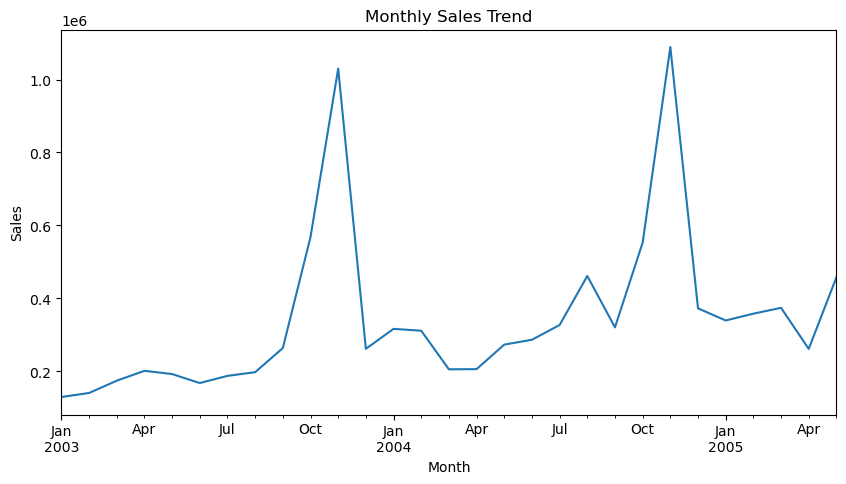

In [27]:
Sales_df.plot_sales_trend()

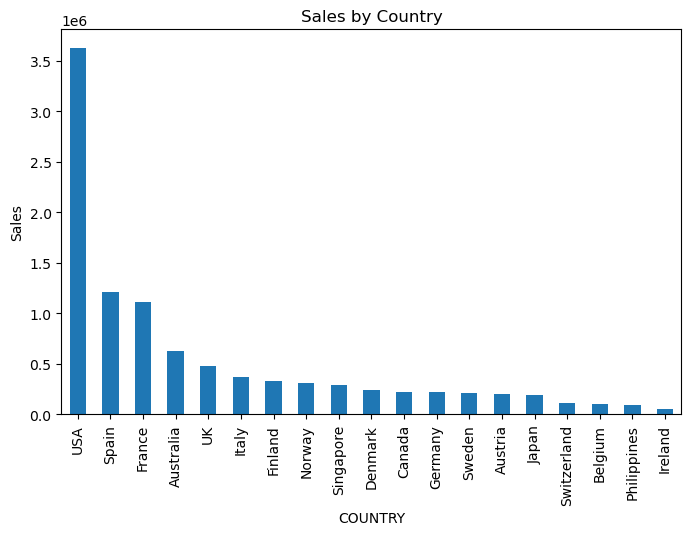

In [28]:
Sales_df.plot_sales_by_region()

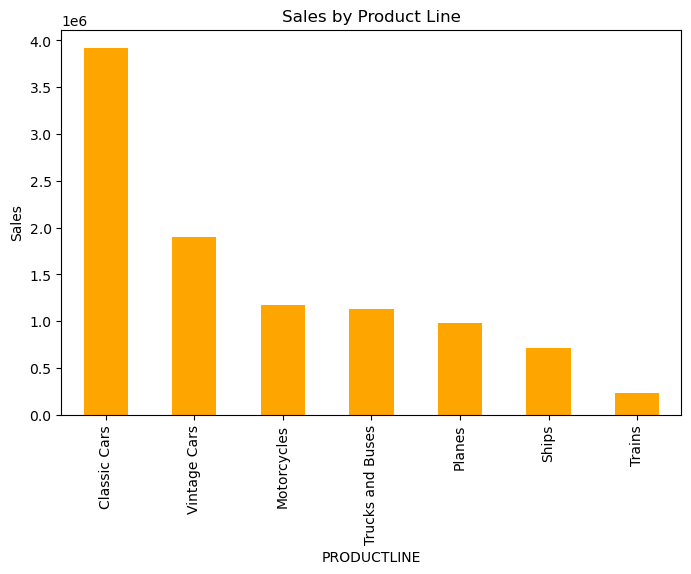

In [30]:
Sales_df.plot_sales_by_category()

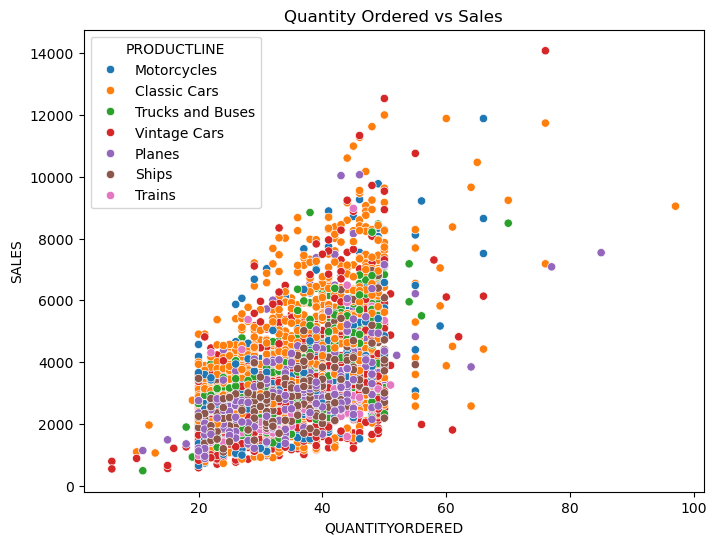

In [31]:
Sales_df.plot_profit_vs_sales()

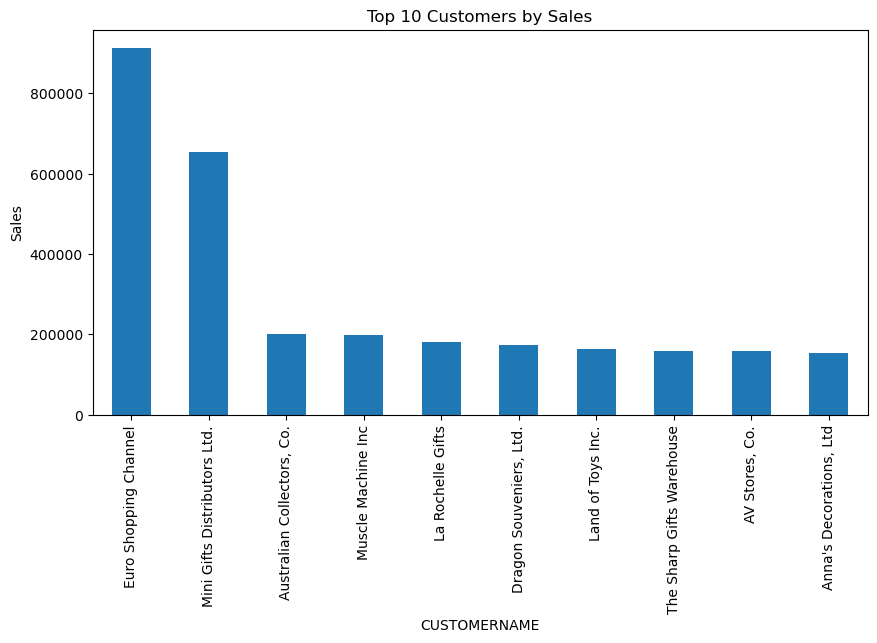

In [32]:
Sales_df.plot_top_customers()

In [36]:
Sales_df.detect_outliers("SALES")

[10993.5,
 8014.82,
 9064.89,
 8014.82,
 10172.7,
 11623.7,
 8254.8,
 12001.0,
 9264.86,
 8892.9,
 8714.7,
 8065.89,
 9774.03,
 8336.94,
 11886.6,
 9218.16,
 9661.44,
 8008.56,
 9245.76,
 8296.35,
 9160.36,
 9631.0,
 8690.36,
 11279.2,
 8023.29,
 8594.52,
 8887.7,
 8602.92,
 8378.58,
 10606.2,
 8411.56,
 7975.44,
 8677.8,
 8470.14,
 7969.36,
 8284.0,
 8339.8,
 8118.55,
 8648.64,
 8378.69,
 8236.75,
 8138.76,
 9470.94,
 8253.0,
 9048.16,
 8374.69,
 9240.44,
 8160.3,
 8078.4,
 14082.8,
 8448.64,
 9169.0,
 8884.8,
 12536.5,
 9534.5,
 8272.34,
 8257.0,
 8209.44,
 8331.61,
 8754.69,
 8291.04,
 8940.96,
 8289.05,
 11887.8,
 11336.7,
 8935.5,
 8427.02,
 10468.9,
 8258.0,
 9720.0,
 8344.71,
 8498.0,
 10758.0,
 11739.7,
 9240.0,
 10039.6,
 8844.12,
 8209.44,
 8977.05,
 10066.6,
 9558.8]

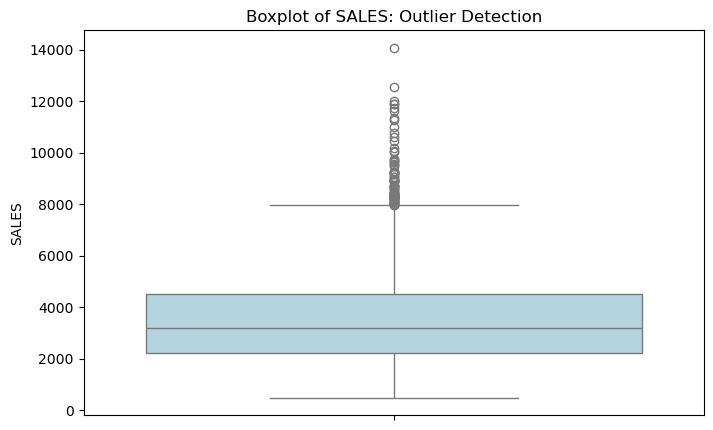

In [41]:
Sales_df.box_plot_outliers("SALES")

In [42]:
Sales_df.chi2_test("COUNTRY", "PRODUCTLINE")

{'chi2_stat': 526.4732187454205, 'p_value': 2.6445129088921646e-56}

In [43]:
Sales_df.anova_test("SALES", "COUNTRY")

{'f_stat': 0.7389884906785258, 'p_value': 0.7729502139369222}

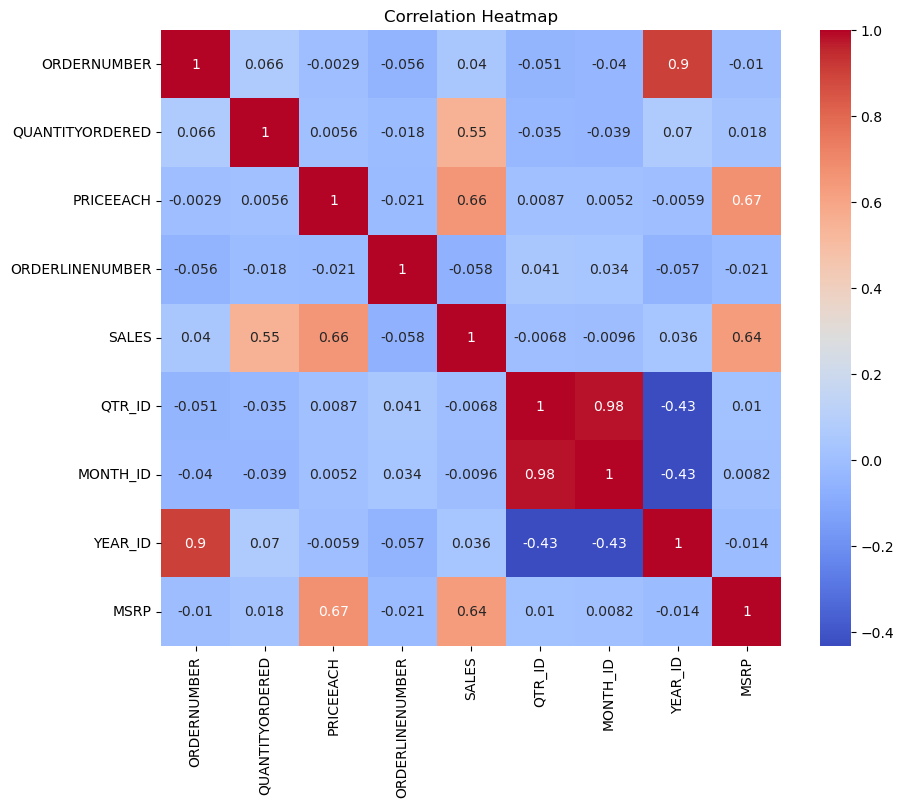

In [46]:
Sales_df.correlation_heatmap()